<a href="https://colab.research.google.com/github/Ashishsantoshsharma/Sales-Analytics-Project/blob/main/superstore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/train.csv.zip')
# Make plots look clean
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
# check data
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   Int64         
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [ ]:
df.shape

(9800, 18)

In [ ]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales']

In [ ]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
# Fix:missing Postal Code (only 11 rows)
df['Postal Code'].fillna(0, inplace=True)
# Fix postal code
df['Postal Code'] = df['Postal Code'].astype('Int64')

/tmp/ipykernel_6239/3436300401.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Postal Code'].fillna(0, inplace=True)


In [ ]:
df.describe().round()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Shipping Days
count,9800.0,9800,9800,9800.0,9800.0,9800.0
mean,4900.0,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55211.0,231.0,4.0
min,1.0,2015-01-03 00:00:00,2015-01-07 00:00:00,0.0,0.0,0.0
25%,2451.0,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.0,17.0,3.0
50%,4900.0,2017-06-26 00:00:00,2017-06-29 00:00:00,57551.0,54.0,4.0
75%,7350.0,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.0,211.0,5.0
max,9800.0,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.0,22638.0,7.0
std,2829.0,NaN,NaN,32077.0,627.0,2.0


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%d/%m/%Y')
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Shipping Days'].describe()

,Shipping Days
count,9800.000000
mean,3.961122
std,1.749614
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,7.000000


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

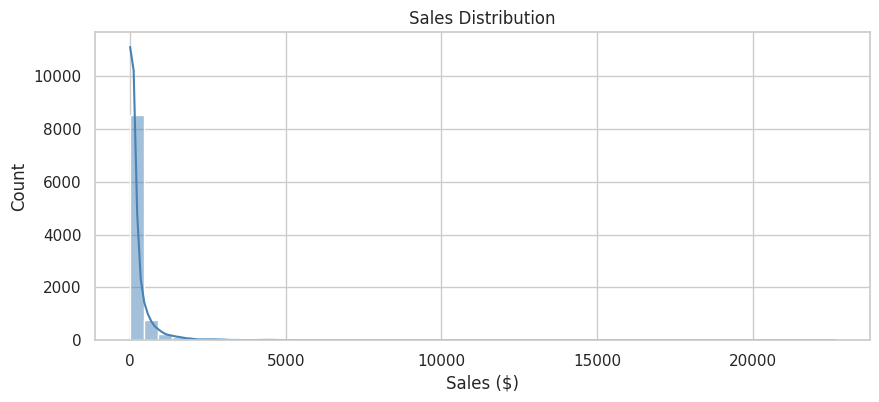

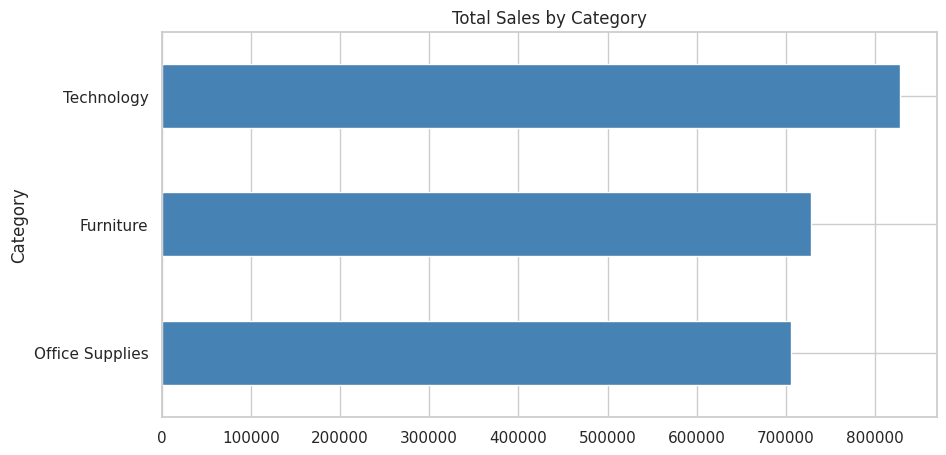

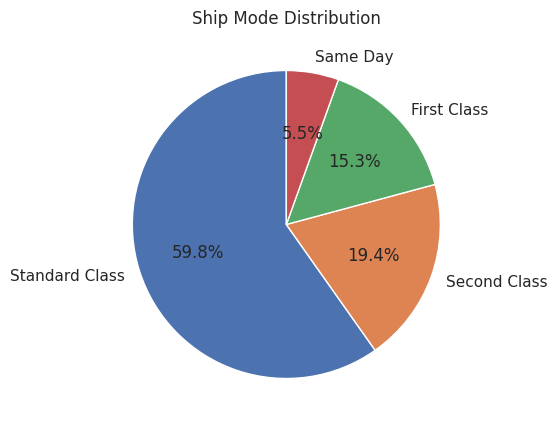

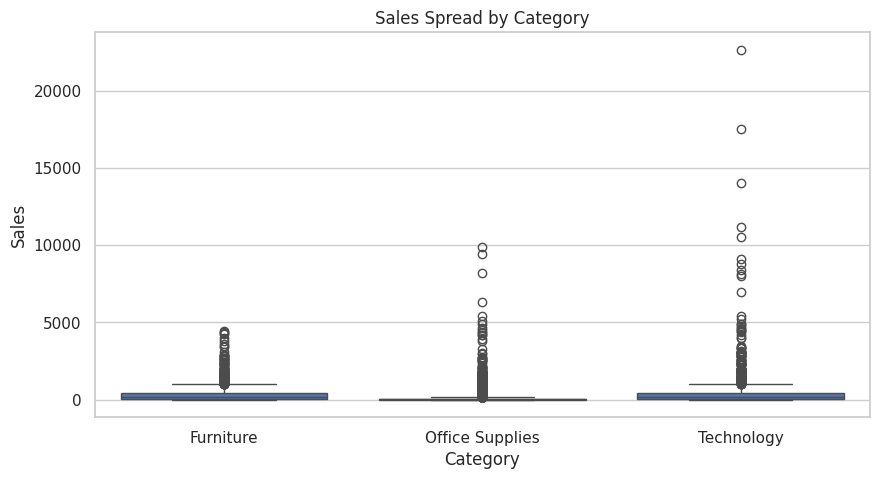

In [ ]:
# Sales distribution (histogram)
plt.figure(figsize=(10, 4))
sns.histplot(df['Sales'], bins=50, kde=True, color='steelblue')
plt.title('Sales Distribution')
plt.xlabel('Sales ($)')
plt.show()

# Sales by Category (bar chart)
df.groupby('Category')['Sales'].sum().sort_values().plot(
    kind='barh', color='steelblue', title='Total Sales by Category'
)
plt.show()

# Ship Mode (pie chart)
df['Ship Mode'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90
)
plt.title('Ship Mode Distribution')
plt.ylabel('')
plt.show()

# Box plot: Sales by Category
sns.boxplot(data=df, x='Category', y='Sales')
plt.title('Sales Spread by Category')
plt.show()

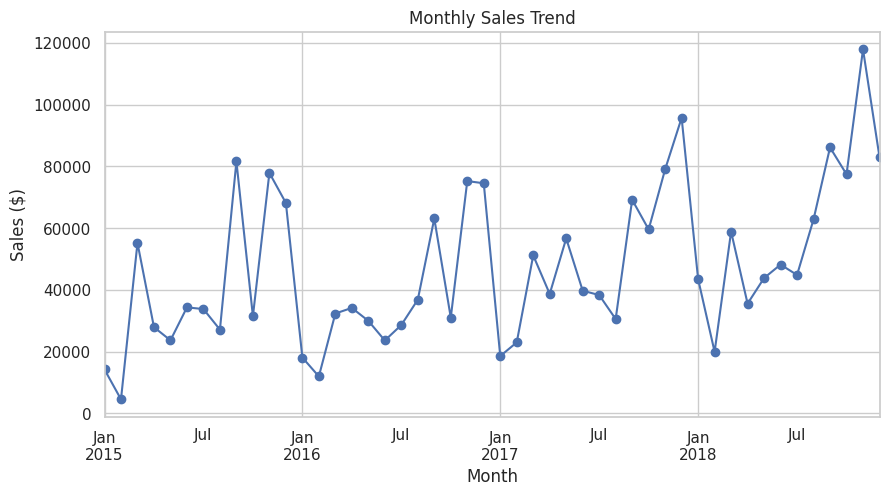

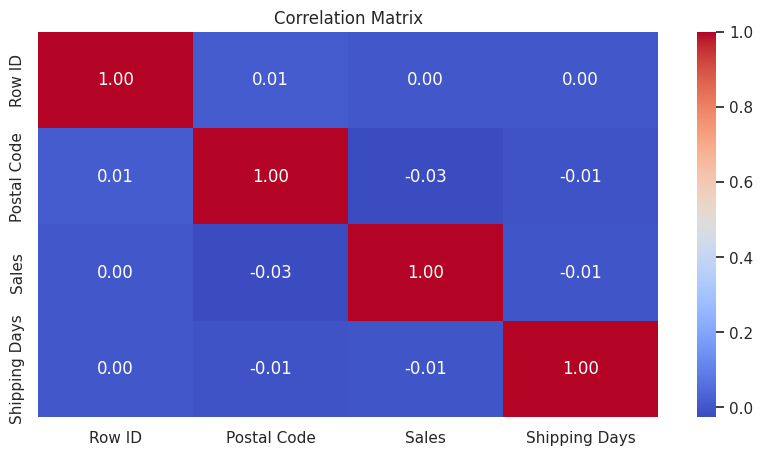

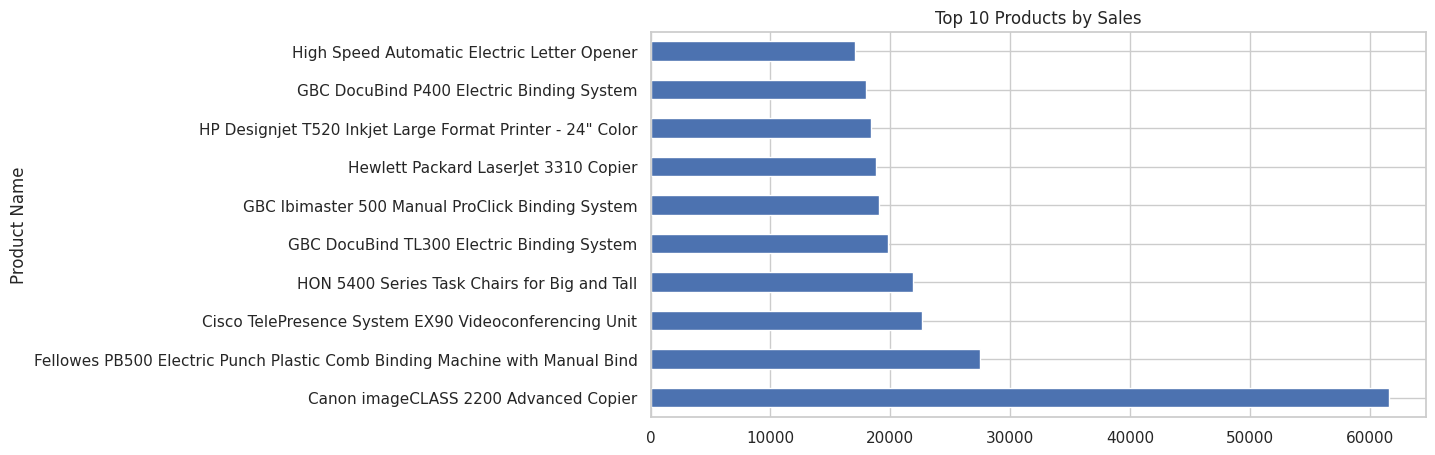

In [ ]:
# Monthly Sales Trend
df['Month'] = df['Order Date'].dt.to_period('M')
monthly = df.groupby('Month')['Sales'].sum()

monthly.plot(kind='line', marker='o', title='Monthly Sales Trend')
plt.ylabel('Sales ($)')
plt.show()

# Sales by Region
df.groupby('Region')['Sales'].agg(['sum', 'mean', 'count'])

# Avg Shipping Days by Ship Mode
df.groupby('Ship Mode')['Shipping Days'].mean().sort_values()

# Correlation heatmap (numeric columns only)
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Top 10 products by sales
top10 = df.groupby('Product Name')['Sales'].sum() \
           .sort_values(ascending=False).head(10)
top10.plot(kind='barh', title='Top 10 Products by Sales')
plt.show()

In [ ]:
df.to_csv('superstore_cleaned project 1.csv', index=False)